In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import genextreme as gev

# === 加载数据 ===
ecmwf_ds = xr.open_dataset("IFS_t2m_hottest_month.nc")
rl_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
mask_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")

# === 基本信息 ===
region_ids = mask_ds['region_id'].values
lat_1d = mask_ds['latitude'].values
lon_1d = mask_ds['longitude'].values

# 构造2D纬度场（关键！）
lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)

t2m_ifs_all = ecmwf_ds['t2m_hottest_month']
t2m_berkeley_all = rl_ds['t2m_hottest']

n_regions = 237

time_periods = [
    (1981, 1990),
    (1991, 2000),
    (2001, 2010),
    (2011, 2020),
    (2020, 2024)
]

n_periods = len(time_periods)

# === 工具函数 ===
def get_max_before_year(ds, start, end):
    sub = ds.sel(year=(ds.year >= start) & (ds.year <= end))
    return sub['t2m_hottest'].max(dim='year')

# === 初始化概率矩阵 ===
prob_map = np.full((n_regions, n_periods), np.nan)

# =========================================================
# === 计算破纪录概率
# =========================================================
for i, (start, end) in enumerate(time_periods):
    print(f"Processing {start}-{end}...")

    period_mask_ifs = (ecmwf_ds.year >= start) & (ecmwf_ds.year <= end)
    period_mask_berkeley = (rl_ds.year >= start) & (rl_ds.year <= end)

    t2m_ifs_period = t2m_ifs_all.sel(year=period_mask_ifs)
    t2m_berkeley_period = t2m_berkeley_all.sel(year=period_mask_berkeley)

    ifs_mean = t2m_ifs_period.mean(dim='year')
    berkeley_mean = t2m_berkeley_period.mean(dim='year')

    # bias correction
    t2m_corrected = t2m_ifs_period - ifs_mean + berkeley_mean

    max_t2m = get_max_before_year(rl_ds, 1940, start-1)

    values = t2m_corrected.values.transpose(0, 2, 1).reshape(-1, n_regions)

    for r in range(n_regions):
        series = values[:, r]
        series = series[~np.isnan(series)]

        if len(series) < 30:
            continue

        try:
            c, loc, scale = gev.fit(series)
            x = max_t2m.sel(region_id=r).item()
            F = gev.cdf(x, c, loc=loc, scale=scale)
            prob_map[r, i] = 1 - F
        except Exception:
            continue


# =========================================================
# === ✅ 构造区域纬度（关键步骤）
# =========================================================

# 计算每个 region 的平均纬度
region_lat = np.full(n_regions, np.nan)

for r in range(n_regions):
    mask = (region_ids == r)
    if np.any(mask):
        region_lat[r] = np.nanmean(lat2d[mask])

# =========================================================
# === ✅ 统计（核心部分）
# =========================================================

threshold = 0.2  # 20%

results = []

for i in range(n_periods):
    prob = prob_map[:, i]

    # === 条件：prob > 0.2 ===
    valid = prob > threshold

    # === 1. 全球（仅 60S 以北） ===
    mask_global = region_lat > -60
    total_global = np.sum(mask_global)
    count_global = np.sum(valid & mask_global)

    ratio_global = count_global / total_global

    # === 2. 热带 (15S–15N) ===
    mask_tropics = (region_lat >= -15) & (region_lat <= 15)
    ratio_tropics = np.sum(valid & mask_tropics) / np.sum(mask_tropics)

    # === 3. 南半球中纬度 (60S–15S) ===
    mask_south_mid = (region_lat > -60) & (region_lat < -15)
    ratio_south_mid = np.sum(valid & mask_south_mid) / np.sum(mask_south_mid)

    # === 4. 北半球中纬度 (15N–45N) ===
    mask_north_mid = (region_lat > 15) & (region_lat <= 45)
    ratio_north_mid = np.sum(valid & mask_north_mid) / np.sum(mask_north_mid)

    # === 5. 高纬 (45N以北) ===
    mask_high_north = region_lat > 45
    ratio_high_north = np.sum(valid & mask_high_north) / np.sum(mask_high_north)

    results.append([
        ratio_global,
        ratio_tropics,
        ratio_south_mid,
        ratio_north_mid,
        ratio_high_north
    ])

# =========================================================
# === 转成表格
# =========================================================

period_labels = [f"{start}-{end}" for start, end in time_periods]

df = pd.DataFrame(
    np.array(results).T,
    index=[
        "Global (>60S)",
        "Tropics (15S–15N)",
        "SH mid (60S–15S)",
        "NH mid (15N–45N)",
        "NH high (>45N)"
    ],
    columns=period_labels
)

# 转百分比
df = df * 100

# 保留1位小数
df = df.round(1)

print("\n=== Record-breaking probability (>20%) regional ratios (%) ===")
print(df)

# 保存
# df.to_csv("record_breaking_probability_summary.csv")
# print("\nSaved to record_breaking_probability_summary.csv")

Processing 1981-1990...
Processing 1991-2000...
Processing 2001-2010...
Processing 2011-2020...
Processing 2020-2024...

=== Record-breaking probability (>20%) regional ratios (%) ===
                   1981-1990  1991-2000  2001-2010  2011-2020  2020-2024
Global (>60S)           16.7       16.7       26.4       23.1       37.0
Tropics (15S–15N)       36.0       34.0       36.0       46.0       42.0
SH mid (60S–15S)        20.7        6.9       20.7       20.7       34.5
NH mid (15N–45N)        12.7       14.1       32.4       23.9       43.7
NH high (>45N)           4.5       10.6       15.2        6.1       27.3


In [1]:
# ==========================================
# Record-breaking period + frequency + margin statistics
# ==========================================
import xarray as xr
import numpy as np

# ==========================================
# Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

region_id_map = region_mask_ds["region_id"]
lat = region_mask_ds["latitude"].values

# ==========================================
# 纬度筛选（>60S）
# ==========================================
lat_mask = lat > -60
lat_mask_2d = np.repeat(lat_mask[:, np.newaxis], len(region_mask_ds["longitude"]), axis=1)

valid_region_ids = np.unique(region_id_map.values[lat_mask_2d])
valid_region_ids = valid_region_ids[~np.isnan(valid_region_ids)].astype(int)

# ==========================================
# 时间分组
# ==========================================
time_groups = {
    "Before 1981": (1940, 1980),
    "1981–1990": (1981, 1990),
    "1991–2000": (1991, 2000),
    "2001–2010": (2001, 2010),
    "2011–2020": (2011, 2020),
    "2021–2024": (2021, 2024),
}
group_labels = list(time_groups.keys())

years = ds["year"].values
t2m = ds["t2m_hottest"]

# ==========================================
# ⭐ 每个region最大值对应年份（用于分组）
# ==========================================
max_year_idx = t2m.argmax(dim="year")
max_years = xr.DataArray(years[max_year_idx.values], dims=["region_id"])

group_array = np.full(max_years.shape, "", dtype=object)

for label, (start, end) in time_groups.items():
    mask = (max_years.values >= start) & (max_years.values <= end)
    group_array[mask] = label

# ==========================================
# ⭐ 统计1：区域数量比例
# ==========================================
total_regions = 217

print("=== Percentage of regions (>60S) by record-breaking period ===\n")

for label in group_labels:

    mask = (group_array == label)
    region_ids_in_group = np.where(mask)[0]

    selected = np.intersect1d(region_ids_in_group, valid_region_ids)

    count = len(selected)
    percentage = count / total_regions * 100

    print(f"{label:12s}: {count:3d} regions  ({percentage:.2f}%)")

# ==========================================
# ⭐ 统计2：破纪录次数（1981–2024）
# ==========================================
t2m_base = t2m.sel(year=slice(1940, 1980))
record_tracker = t2m_base.max(dim="year")

record_counts = xr.zeros_like(record_tracker)

t2m_analysis = t2m.sel(year=slice(1981, 2024))

for year in t2m_analysis.year.values:

    current = t2m.sel(year=year)

    is_record = current > record_tracker

    record_counts = record_counts + is_record.astype(int)

    record_tracker = xr.where(is_record, current, record_tracker)

record_counts_np = record_counts.values

# ==========================================
# ⭐ 统计3：平均破纪录次数
# ==========================================
print("\n=== Mean record-breaking counts (1981–2024) by group ===\n")

for label in group_labels:

    mask = (group_array == label)
    region_ids_in_group = np.where(mask)[0]

    selected = np.intersect1d(region_ids_in_group, valid_region_ids)

    if len(selected) > 0:
        mean_count = np.mean(record_counts_np[selected])
        print(f"{label:12s}: mean = {mean_count:.2f} (n={len(selected)})")
    else:
        print(f"{label:12s}: no regions")

# ==========================================
# ⭐ 统计4：margin（极端性）
# ==========================================

# baseline统计量
baseline_max = t2m.sel(year=slice(1940, 1980)).max(dim="year")
baseline_std = t2m.sel(year=slice(1940, 1980)).std(dim="year")

# 最新record值（就是全时段最大值）
latest_record = t2m.max(dim="year")

# margin计算
margin = (latest_record - baseline_max) / baseline_std

margin_np = margin.values

# ==========================================
# ⭐ 按分组统计平均margin
# ==========================================
print("\n=== Mean record-breaking margin by group ===\n")

for label in group_labels:

    mask = (group_array == label)
    region_ids_in_group = np.where(mask)[0]

    selected = np.intersect1d(region_ids_in_group, valid_region_ids)

    if len(selected) > 0:
        mean_margin = np.mean(margin_np[selected])
        print(f"{label:12s}: mean margin = {mean_margin:.2f} (n={len(selected)})")
    else:
        print(f"{label:12s}: no regions")

=== Percentage of regions (>60S) by record-breaking period ===

Before 1981 :   5 regions  (2.30%)
1981–1990   :   4 regions  (1.84%)
1991–2000   :  14 regions  (6.45%)
2001–2010   :  29 regions  (13.36%)
2011–2020   :  60 regions  (27.65%)
2021–2024   : 104 regions  (47.93%)

=== Mean record-breaking counts (1981–2024) by group ===

Before 1981 : mean = 0.00 (n=5)
1981–1990   : mean = 1.50 (n=4)
1991–2000   : mean = 1.57 (n=14)
2001–2010   : mean = 2.69 (n=29)
2011–2020   : mean = 2.70 (n=60)
2021–2024   : mean = 4.03 (n=104)

=== Mean record-breaking margin by group ===

Before 1981 : mean margin = 0.00 (n=5)
1981–1990   : mean margin = 0.73 (n=4)
1991–2000   : mean margin = 1.32 (n=14)
2001–2010   : mean margin = 1.38 (n=29)
2011–2020   : mean margin = 1.52 (n=60)
2021–2024   : mean margin = 2.76 (n=104)


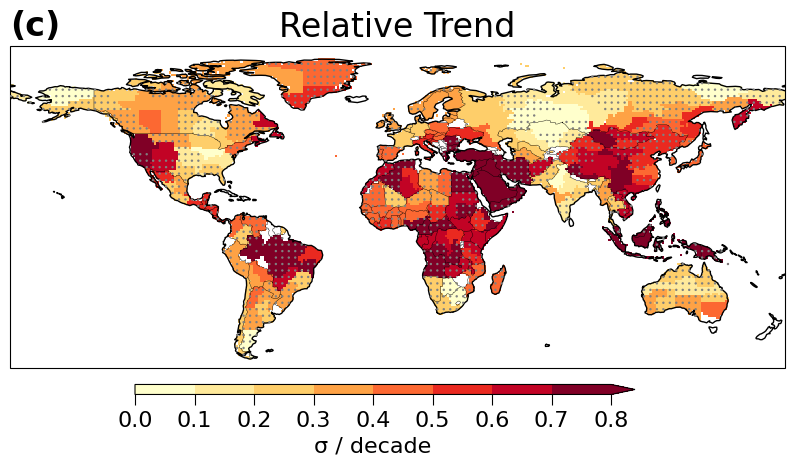

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
import matplotlib.colors as mcolors

# =========================================================
# 1. Load datasets
# =========================================================
ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

region_ids = region_mask_ds['region_id'].values
lat = region_mask_ds['latitude'].values
lon = region_mask_ds['longitude'].values
n_regions = ds.region_id.size

lon2d, lat2d = np.meshgrid(lon, lat)

# =========================================================
# 2. Compute trends 1981-2024
# =========================================================
ds_sel_trend = ds.sel(year=slice(1981, 2024))
years_trend = ds_sel_trend.year.values

trend = np.full((n_regions,), np.nan)

for i in range(n_regions):
    y = ds_sel_trend['t2m_hottest'][:, i].values
    if np.isnan(y).all():
        continue
    slope, _, _, _, _ = linregress(years_trend, y)
    trend[i] = slope * 10.0  # K/decade

# =========================================================
# 3. Compute sigma 1940-1980
# =========================================================
ds_sel_sigma = ds.sel(year=slice(1940, 1980))
sigma = np.full((n_regions,), np.nan)

for i in range(n_regions):
    y = ds_sel_sigma['t2m_hottest'][:, i].values
    if np.isnan(y).all():
        continue
    sigma[i] = np.nanstd(y, ddof=1)

# =========================================================
# 4. Compute trend / sigma ratio
# =========================================================
trend_sigma_ratio = trend / sigma

# =========================================================
# 5. Map ratio to lat-lon grid
# =========================================================
ratio_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue
    rid = int(rid)
    if rid < n_regions:
        ratio_map[region_ids == rid] = trend_sigma_ratio[rid]

# =========================================================
# 6. Apply fidelity mask
# =========================================================
fidelity_mask = (fidelity_ds['fidelity_score'] == 3).values
GREY_VAL = -9999

masked_ratio = ratio_map.copy()

# 强制最小值为0（可根据需要调整）
MIN_LEVEL = 0
masked_ratio[(masked_ratio > GREY_VAL) & (masked_ratio < MIN_LEVEL)] = MIN_LEVEL

# Scatter mask for low fidelity
SCATTER_STEP = 3
low_fidelity_mask = (~fidelity_mask) & (~np.isnan(region_ids))
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = low_fidelity_mask & sparse_mask

# =========================================================
# 7. Colormap
# =========================================================
levels = np.arange(0, 0.81, 0.1)  # ratio 的范围，可以调整
colors = plt.get_cmap("YlOrRd")(np.linspace(0, 1, len(levels) - 1))
cmap = mcolors.ListedColormap(['silver'] + list(colors))
bounds = [GREY_VAL - 0.5] + list(levels)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# =========================================================
# 8. Plot
# =========================================================
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

im = ax.pcolormesh(
    lon,
    lat,
    masked_ratio,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Scatter low fidelity
ax.scatter(
    lon2d[low_fidelity_sparse],
    lat2d[low_fidelity_sparse],
    s=3,
    color="grey",
    marker="o",
    edgecolors="none",
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())
ax.set_title("Relative Trend", fontsize=24)

ax.text(
    0.0,
    1.03,
    '(c)',
    transform=ax.transAxes,
    fontsize=24,
    fontweight='bold',
    ha="left"
)

# =========================================================
# 9. Colorbar
# =========================================================
cmap_cbar = mcolors.ListedColormap(colors)
norm_cbar = mcolors.BoundaryNorm(levels, cmap_cbar.N)

sm = plt.cm.ScalarMappable(cmap=cmap_cbar, norm=norm_cbar)
sm.set_array([])

cbar_ax = fig.add_axes([0.25, 0.12, 0.5, 0.02])
ticks = np.arange(0, 0.81, 0.1)

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=ticks,
    extend="max"
)
cbar.ax.tick_params(labelsize=16, length=8)
cbar.set_label("σ / decade", fontsize=16)

# =========================================================
# 10. Save
# =========================================================
plt.savefig(
    "ERA5_t2m_trend_over_sigma_1940_1980.pdf",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [9]:
import xarray as xr
import numpy as np
import pandas as pd

# ==========================================
# Load data
# ==========================================
ds = xr.open_dataset(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc"
).sel(year=slice(1940, 2024))

region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

region_id_map = region_mask_ds["region_id"]
lat_1d = region_mask_ds["latitude"].values
lon_1d = region_mask_ds["longitude"].values

lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)

# ==========================================
# 纬度筛选（>60S）
# ==========================================
lat_mask = lat_1d > -60
lat_mask_2d = np.repeat(lat_mask[:, np.newaxis], len(lon_1d), axis=1)

valid_region_ids = np.unique(region_id_map.values[lat_mask_2d])
valid_region_ids = valid_region_ids[~np.isnan(valid_region_ids)].astype(int)

# ==========================================
# 每个region平均纬度
# ==========================================
n_regions = int(np.nanmax(region_id_map.values)) + 1
region_lat = np.full(n_regions, np.nan)

for r in valid_region_ids:
    mask = (region_id_map.values == r)
    if np.any(mask):
        region_lat[r] = np.nanmean(lat2d[mask])

# ==========================================
# 纬度带定义 + region筛选
# ==========================================
lat_bands = {
    "60S–15S": (region_lat > -60) & (region_lat <= -15),
    "15S–15N": (region_lat > -15) & (region_lat <= 15),
    "15N–45N": (region_lat > 15) & (region_lat <= 45),
    ">45N": (region_lat > 45)
}

band_region_ids = {
    band: np.where(mask & np.isin(np.arange(n_regions), valid_region_ids))[0]
    for band, mask in lat_bands.items()
}

# ⭐ 加这一行：全球
band_region_ids["Global (>60S)"] = valid_region_ids

# ==========================================
# ENSO定义
# ==========================================
ENSO_PHASES = {
    "El Niño DEV": [1982, 1986, 1991, 1997, 2002, 2004, 2006, 2009, 2015, 2018, 2023],
    "El Niño DEC": [1983, 1987, 1992, 1998, 2003, 2005, 2007, 2010, 2016, 2019, 2024],
    "La Niña DEV": [1984, 1988, 1998, 2007, 2010, 2016, 2020],
    "La Niña DEC": [1985, 1989, 2001, 2008, 2012, 2017, 2022]
}

# ==========================================
# 数据变量
# ==========================================
t2m = ds["t2m_hottest"]

# ==========================================
# baseline
# ==========================================
record_tracker = t2m.sel(year=slice(1940, 1980)).max(dim="year")

# ==========================================
# 每年破纪录
# ==========================================
record_map = {}

for year in range(1981, 2025):
    current = t2m.sel(year=year).values
    record_vals = record_tracker.values

    is_record = current > record_vals
    record_map[year] = is_record.copy()

    record_tracker.values = np.maximum(record_vals, current)

# ==========================================
# 统计函数（复用逻辑）
# ==========================================
def compute_mean_prob(region_ids):
    n_reg = len(region_ids)
    row = []

    for phase, phase_years in ENSO_PHASES.items():
        yearly_fraction = []

        for y in phase_years:
            if y in record_map and n_reg > 0:
                count = np.sum(record_map[y][region_ids])
                frac = count / n_reg
                yearly_fraction.append(frac)

        mean_prob = np.mean(yearly_fraction) if len(yearly_fraction) > 0 else np.nan
        row.append(mean_prob)

    return row

# ==========================================
# 计算所有纬度带 + 全球
# ==========================================
result_matrix = []

for band_name, region_ids in band_region_ids.items():
    result_matrix.append(compute_mean_prob(region_ids))

# ==========================================
# 输出
# ==========================================
df = pd.DataFrame(
    result_matrix,
    index=list(band_region_ids.keys()),
    columns=list(ENSO_PHASES.keys())
)

df = df * 100
df = df.round(1)

print("\n=== Mean annual record probability per region (%) ===\n")
print(df)

# df.to_csv("enso_latband_record_probability.csv")


=== Mean annual record probability per region (%) ===

               El Niño DEV  El Niño DEC  La Niña DEV  La Niña DEC
60S–15S                7.8          5.3          3.9          2.5
15S–15N               10.4         22.4         17.1          1.4
15N–45N                7.9         11.9          9.7          6.6
>45N                   4.8          6.1          7.6          6.3
Global (>60S)          7.5         11.7         10.0          4.8
